# TensorBoard Run Comparison

Load TensorBoard event files for `base`, `flex`, `ftnet`, and `gcn`, then compare rewards, losses, curricula, and `Train/mean_reward`.

In [1]:
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

plt.style.use("ggplot")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

LOG_ROOT = Path("/home/dung-admin/quadloco_ws/quadlocofault/logs/rsl_rl")
GROUP = "rough"  # change to "flat" if needed
MODELS = ["base", "flex", "ftnet", "gcn"]
SMOOTHING = 1  # set >1 to smooth with rolling mean

RUN_NAMES = {
    model: f"unitree_go2_{GROUP}_{model}"
    for model in MODELS
}

RUN_NAMES

{'base': 'unitree_go2_rough_base',
 'flex': 'unitree_go2_rough_flex',
 'ftnet': 'unitree_go2_rough_ftnet',
 'gcn': 'unitree_go2_rough_gcn'}

In [2]:
def latest_event_file(run_dir: Path) -> Path:
    event_files = sorted(run_dir.glob("**/events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event file found under {run_dir}")
    return max(event_files, key=lambda path: path.stat().st_mtime)


def load_scalars(event_file: Path) -> pd.DataFrame:
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    rows = []
    for tag in ea.Tags().get("scalars", []):
        for event in ea.Scalars(tag):
            rows.append(
                {
                    "tag": tag,
                    "step": event.step,
                    "wall_time": event.wall_time,
                    "value": event.value,
                }
            )
    if not rows:
        return pd.DataFrame(columns=["tag", "step", "wall_time", "value"])
    return pd.DataFrame(rows)


def smooth_series(frame: pd.DataFrame, window: int) -> pd.DataFrame:
    if window <= 1:
        return frame.copy()
    out = frame.sort_values("step").copy()
    out["value"] = out["value"].rolling(window=window, min_periods=1).mean()
    return out


def tags_with_prefix(tags: Iterable[str], prefix: str) -> list[str]:
    return sorted(tag for tag in tags if tag.startswith(prefix))


In [3]:
event_files = {
    model: latest_event_file(LOG_ROOT / run_name)
    for model, run_name in RUN_NAMES.items()
}

event_files

{'base': PosixPath('/home/dung-admin/quadloco_ws/quadlocofault/logs/rsl_rl/unitree_go2_rough_base/2026-06-10_14-22-50/events.out.tfevents.1781094182.ratadmin-Precision-7780.3014963.0'),
 'flex': PosixPath('/home/dung-admin/quadloco_ws/quadlocofault/logs/rsl_rl/unitree_go2_rough_flex/2026-06-10_23-36-44/events.out.tfevents.1781127415.ratadmin-Precision-7780.3402799.0'),
 'ftnet': PosixPath('/home/dung-admin/quadloco_ws/quadlocofault/logs/rsl_rl/unitree_go2_rough_ftnet/2026-06-10_19-50-55/events.out.tfevents.1781113866.ratadmin-Precision-7780.1343491.0'),
 'gcn': PosixPath('/home/dung-admin/quadloco_ws/quadlocofault/logs/rsl_rl/unitree_go2_rough_gcn/2026-06-11_03-18-37/events.out.tfevents.1781140729.ratadmin-Precision-7780.1242976.0')}

In [4]:
scalar_frames = {}
for model, event_file in event_files.items():
    frame = load_scalars(event_file)
    frame["model"] = model
    scalar_frames[model] = frame

all_scalars = pd.concat(scalar_frames.values(), ignore_index=True)
all_scalars.head()

,tag,step,wall_time,value,model
0,Episode_Reward/track_lin_vel_xy_exp,0,1.781094e+09,0.002529,base
1,Episode_Reward/track_lin_vel_xy_exp,1,1.781094e+09,0.007646,base
2,Episode_Reward/track_lin_vel_xy_exp,2,1.781094e+09,0.010184,base
3,Episode_Reward/track_lin_vel_xy_exp,3,1.781094e+09,0.014680,base
4,Episode_Reward/track_lin_vel_xy_exp,4,1.781094e+09,0.019773,base


In [5]:
available_tags = sorted(all_scalars["tag"].unique())
pd.Series(available_tags, name="tag")

0     Curriculum/actuator_faults/mean_achieved_reward
1         Curriculum/actuator_faults/mean_fault_level
2             Curriculum/actuator_faults/move_up_rate
3      Curriculum/terrain_levels/mean_achieved_reward
4        Curriculum/terrain_levels/mean_terrain_level
5            Curriculum/terrain_levels/move_down_rate
6              Curriculum/terrain_levels/move_up_rate
7                           Episode_Reward/VHIP_style
8                       Episode_Reward/action_rate_l2
9                        Episode_Reward/ang_vel_xy_l2
10                      Episode_Reward/base_height_l2
11                          Episode_Reward/dof_acc_l2
12                       Episode_Reward/feet_air_time
13                 Episode_Reward/flat_orientation_l2
14               Episode_Reward/joint_motion_cosmetic
15                        Episode_Reward/lin_vel_z_l2
16                 Episode_Reward/track_ang_vel_z_exp
17                Episode_Reward/track_lin_vel_xy_exp
18                   Episode

In [22]:
def plot_tags(tag_list: list[str], 
              title: str, ncols: int = 2, 
              figsize_scale: tuple[float, float] = (7.0, 3.8),
              save_pdf: bool = False,
              pdf_name: str = None):
    if not tag_list:
        print(f"No tags found for {title}")
        return
    ncols = min(ncols, len(tag_list))
    nrows = (len(tag_list) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows), squeeze=False)
    fig.suptitle(title, fontsize=16)
    axes_flat = axes.flatten()
    for ax, tag in zip(axes_flat, tag_list):
        for model in MODELS:
            frame = all_scalars[(all_scalars["model"] == model) & (all_scalars["tag"] == tag)][["step", "value"]]
            if frame.empty:
                continue
            frame = smooth_series(frame, SMOOTHING)
            ax.plot(frame["step"], frame["value"], label=model)
        ax.set_title(tag)
        ax.set_xlabel("step")
        ax.set_ylabel("value")
        ax.legend()
    for ax in axes_flat[len(tag_list):]:
        ax.axis("off")
    plt.tight_layout()
    if save_pdf:
        if pdf_name is None:
            pdf_name = title
        plt.savefig(f'{pdf_name}.pdf', format="pdf")
    plt.show()

In [7]:
reward_tags = tags_with_prefix(available_tags, "Episode_Reward/")
reward_tags

['Episode_Reward/VHIP_style',
 'Episode_Reward/action_rate_l2',
 'Episode_Reward/ang_vel_xy_l2',
 'Episode_Reward/base_height_l2',
 'Episode_Reward/dof_acc_l2',
 'Episode_Reward/feet_air_time',
 'Episode_Reward/flat_orientation_l2',
 'Episode_Reward/joint_motion_cosmetic',
 'Episode_Reward/lin_vel_z_l2',
 'Episode_Reward/track_ang_vel_z_exp',
 'Episode_Reward/track_lin_vel_xy_exp']

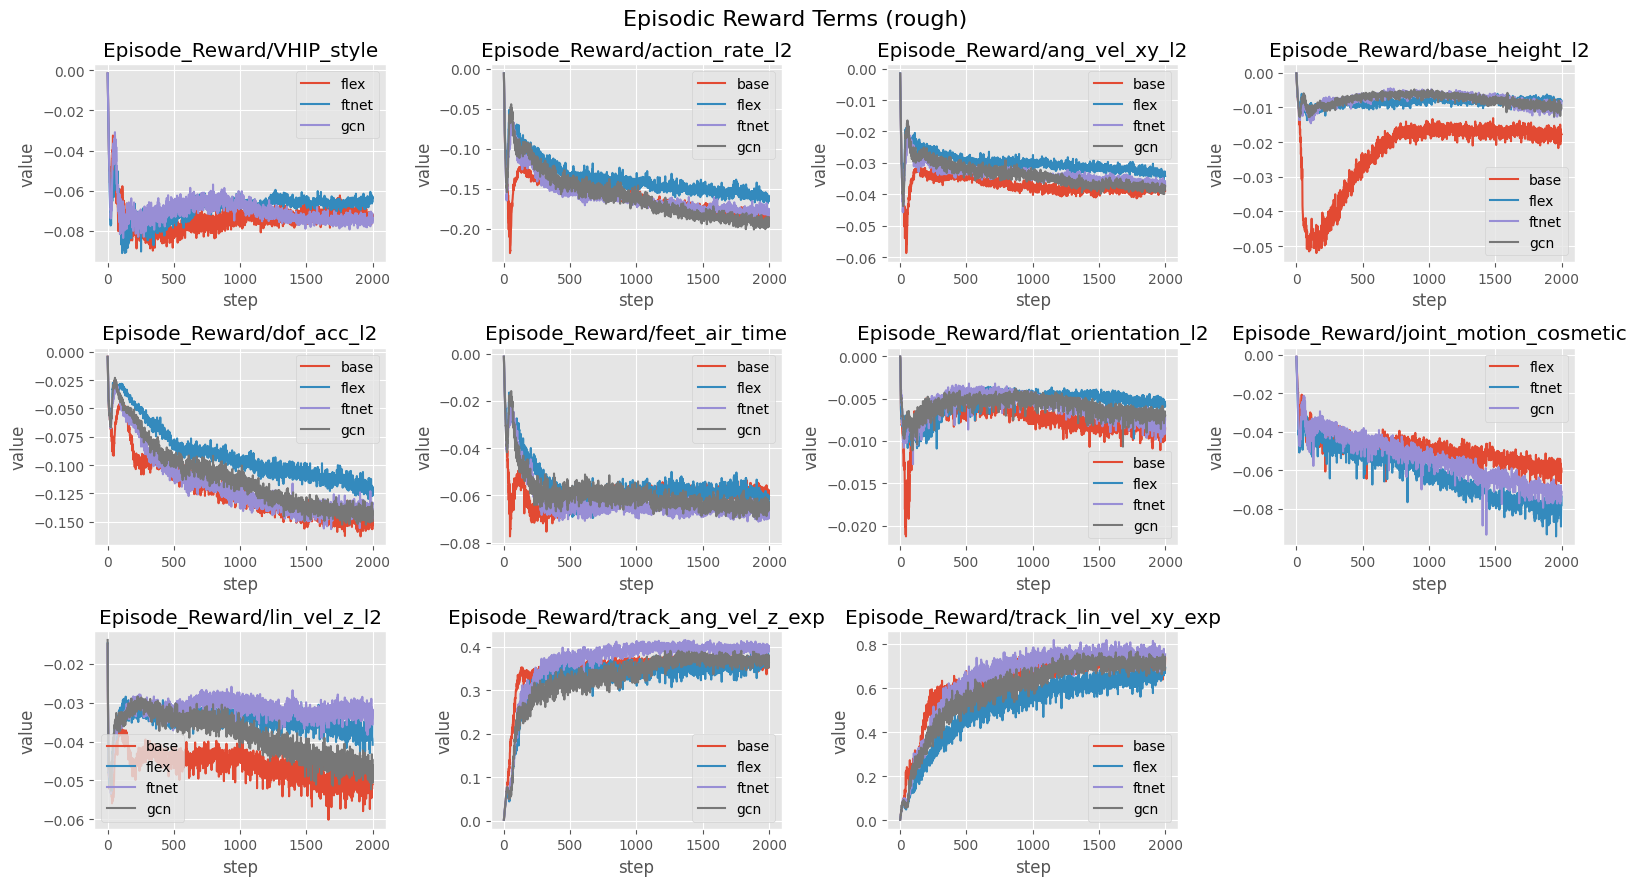

In [29]:
plot_tags(reward_tags, 
          title=f"Episodic Reward Terms ({GROUP})", 
          ncols= 4, 
          figsize_scale=(4.0,3.0),
          save_pdf=True,
          pdf_name="rewards_curve")

In [9]:
loss_tags = tags_with_prefix(available_tags, "Loss/")
loss_tags

['Loss/encoder',
 'Loss/entropy',
 'Loss/fault',
 'Loss/learning_rate',
 'Loss/phys_encoder',
 'Loss/scandots_encoder',
 'Loss/selfsupervised',
 'Loss/surrogate',
 'Loss/value']

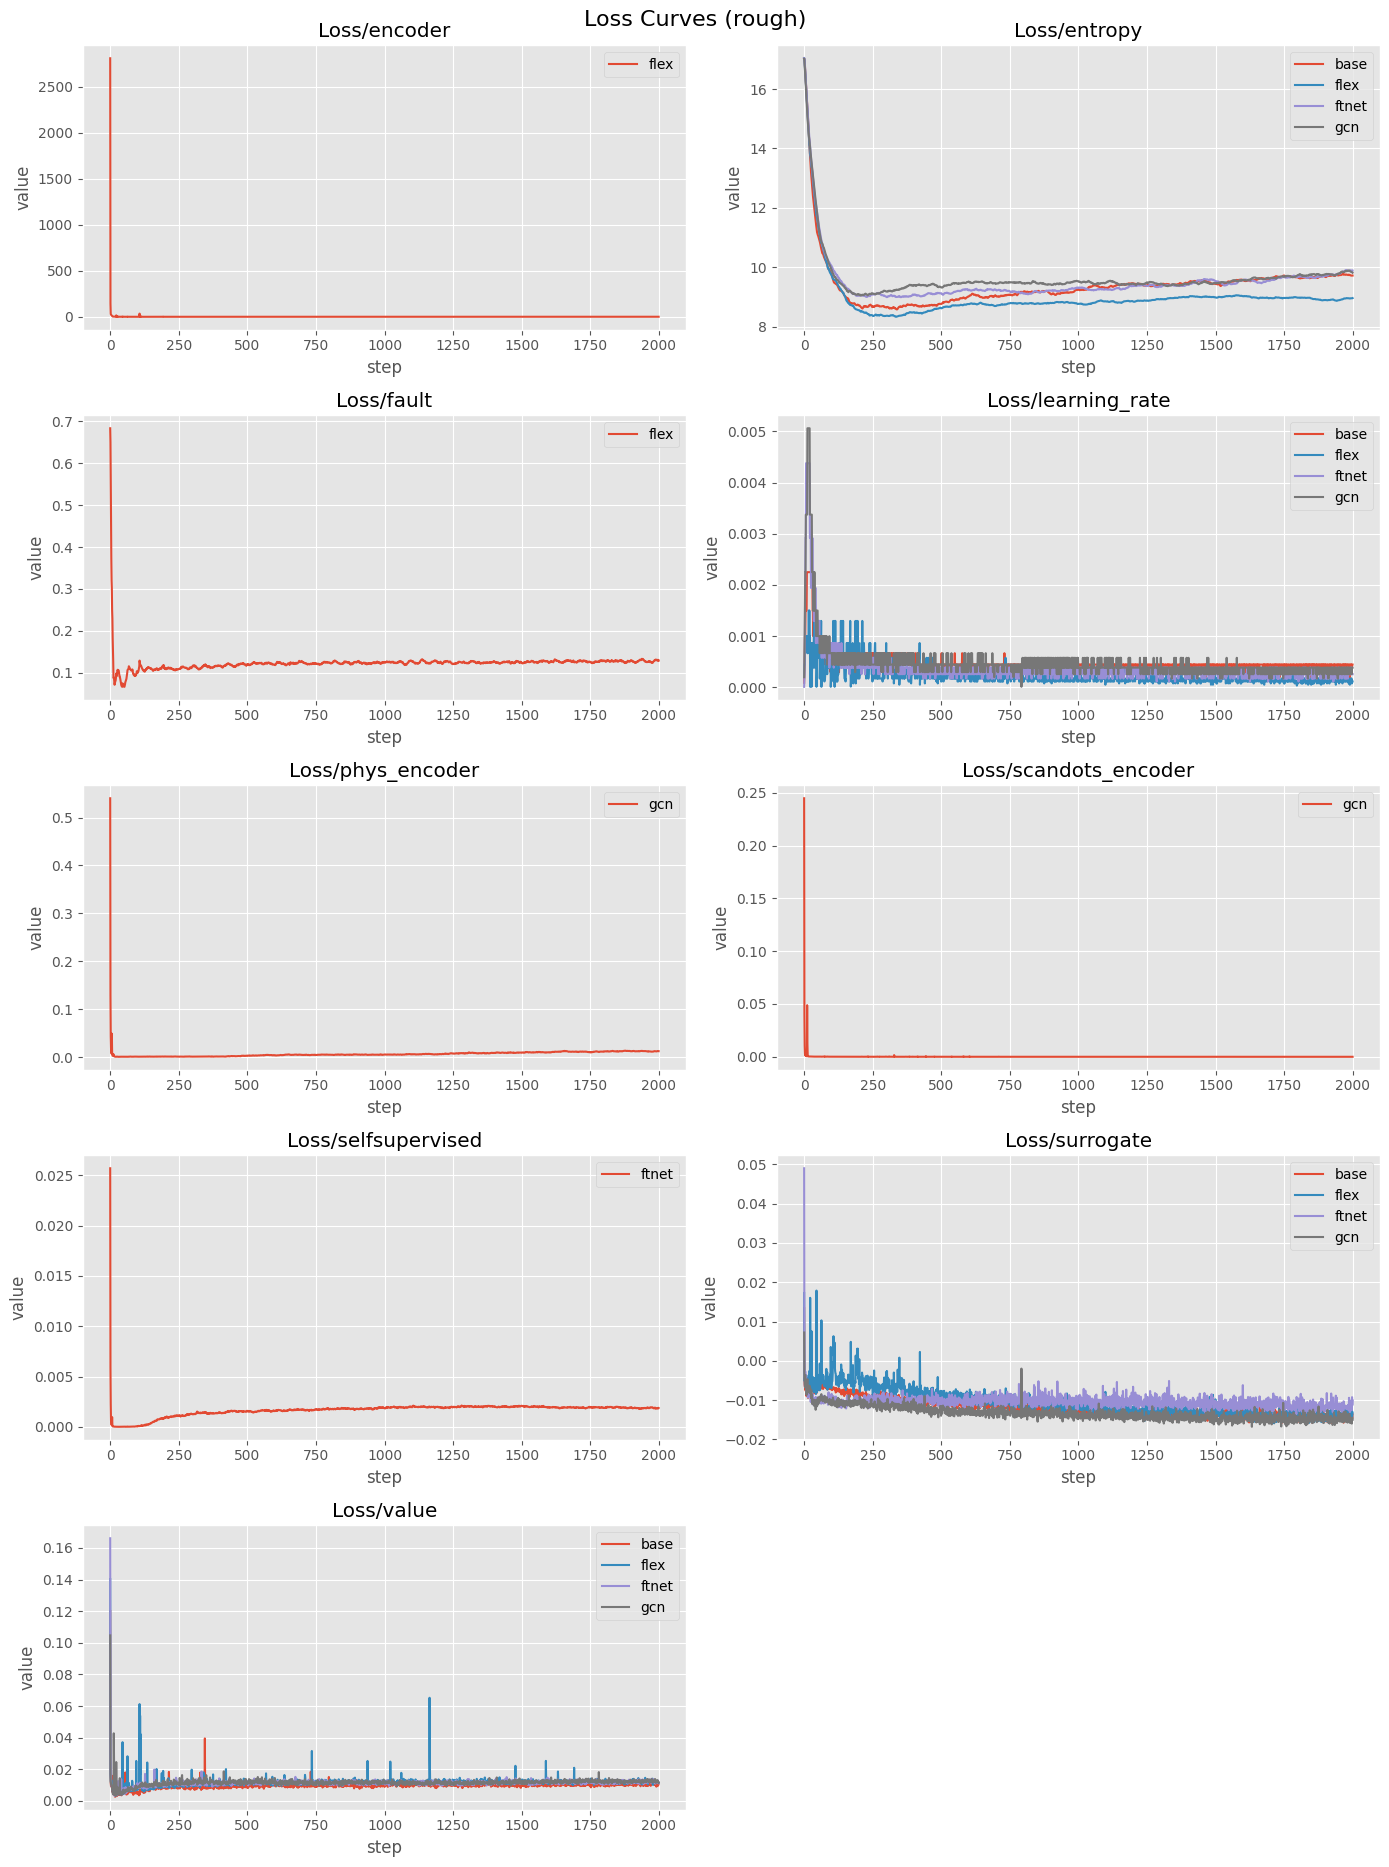

In [10]:
plot_tags(loss_tags, title=f"Loss Curves ({GROUP})")

In [11]:
curriculum_tags = tags_with_prefix(available_tags, "Curriculum/")
curriculum_tags

['Curriculum/actuator_faults/mean_achieved_reward',
 'Curriculum/actuator_faults/mean_fault_level',
 'Curriculum/actuator_faults/move_up_rate',
 'Curriculum/terrain_levels/mean_achieved_reward',
 'Curriculum/terrain_levels/mean_terrain_level',
 'Curriculum/terrain_levels/move_down_rate',
 'Curriculum/terrain_levels/move_up_rate']

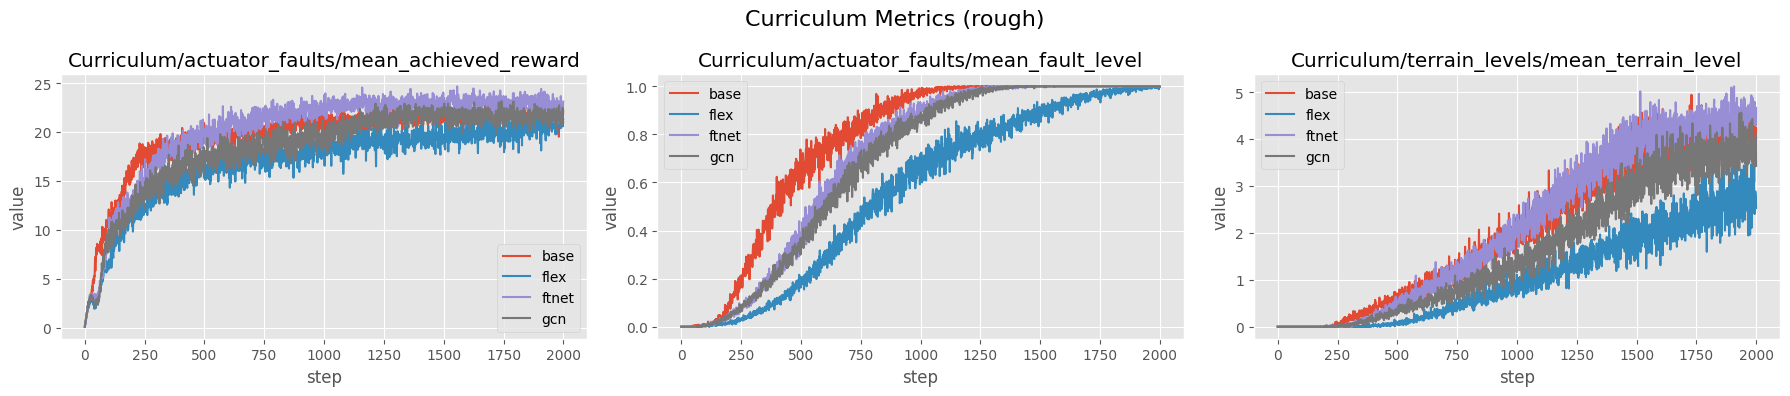

In [27]:
cur_tags = curriculum_tags[0:2]+curriculum_tags[4:5]
plot_tags(cur_tags, 
          ncols = 3, 
          title=f"Curriculum Metrics ({GROUP})", 
          figsize_scale=(6.0,4.0), 
          save_pdf=True,
          pdf_name="curriculum_metrics")

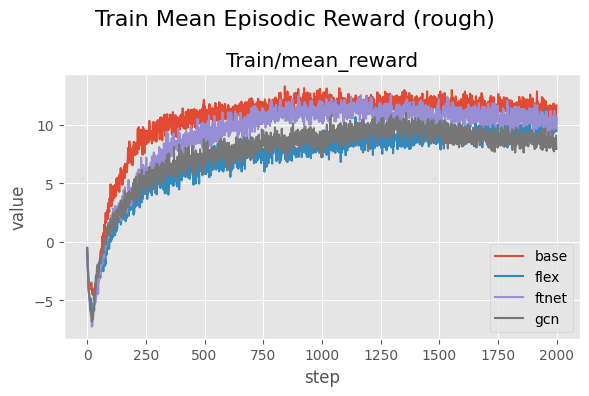

In [28]:
plot_tags(["Train/mean_reward"], 
          title=f"Train Mean Episodic Reward ({GROUP})", 
          ncols=1, 
          figsize_scale=(6.0, 4.0),
          save_pdf=True,
          pdf_name="mean_reward")

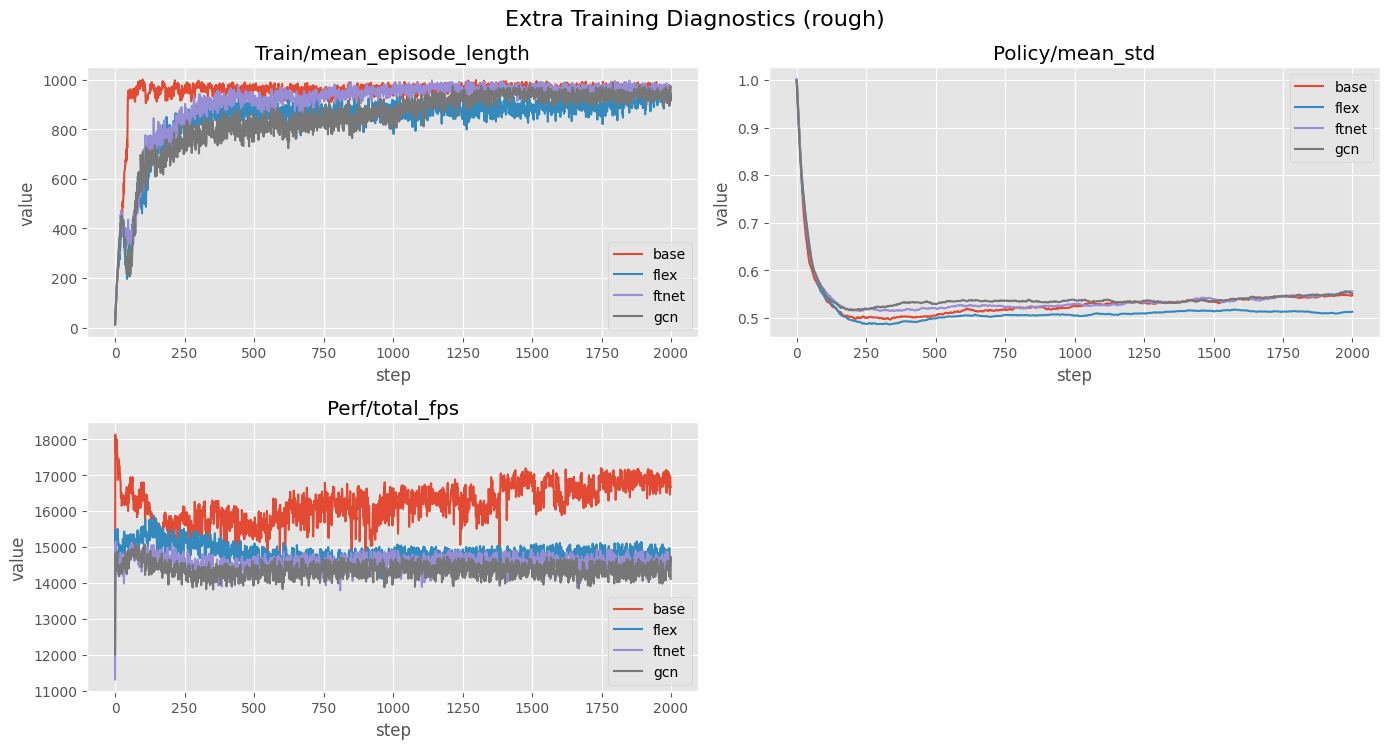

In [14]:
plot_tags(["Train/mean_episode_length", "Policy/mean_std", "Perf/total_fps"], title=f"Extra Training Diagnostics ({GROUP})")

In [15]:
summary_tags = [
    "Train/mean_reward",
    "Curriculum/terrain_levels/mean_terrain_level",
    "Curriculum/actuator_faults/mean_fault_level",
    "Episode_Reward/track_lin_vel_xy_exp",
    "Episode_Reward/track_ang_vel_z_exp",
]

summary_rows = []
for model in MODELS:
    model_frame = all_scalars[all_scalars["model"] == model]
    row = {"model": model}
    for tag in summary_tags:
        tag_frame = model_frame[model_frame["tag"] == tag].sort_values("step")
        row[tag] = tag_frame.iloc[-1]["value"] if not tag_frame.empty else None
    summary_rows.append(row)

pd.DataFrame(summary_rows)

,model,Train/mean_reward,Curriculum/terrain_levels/mean_terrain_level,Curriculum/actuator_faults/mean_fault_level,Episode_Reward/track_lin_vel_xy_exp,Episode_Reward/track_ang_vel_z_exp
0,base,11.680455,3.991766,1.000000,0.735846,0.372786
1,flex,9.491998,2.526637,0.996111,0.694334,0.368952
2,ftnet,10.525297,4.652183,1.000000,0.754157,0.401351
3,gcn,7.967694,3.429167,1.000000,0.687253,0.361457


In [ ]:
# Optional: export all loaded scalars to CSV for external plotting.
# all_scalars.to_csv(Path("/home/dung-admin/quadloco_ws/quadlocofault/notebooks") / f"tensorboard_scalars_{GROUP}.csv", index=False)